In [11]:
import os, warnings, random, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')

In [27]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

In [14]:
%pip install imagehash
#Run this if not installed


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 7.9 MB/s eta 0:00:00


In [15]:
from PIL import Image
import imagehash
import cv2

In [37]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.utils import to_categorical

In [16]:
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)

In [17]:
DATA_DIR      = '/content/drive/MyDrive/dataset/Faulty_solar_panel'
OUTPUT_DIR      = '/content/drive/MyDrive/dataset/output'

CLASS_NAMES = [
    'Clean', 'Dusty', 'Bird-drop',
    'Electrical-damage', 'Physical-Damage', 'Snow-Covered'
]
NUM_CLASSES = len(CLASS_NAMES)

In [53]:
# Image settings
IMG_SIZE      = (224, 224)
IMG_SHAPE     = (*IMG_SIZE, 3)
BATCH_SIZE    = 32
DROPOUT_RATE  = 0.40

# Training hyperparameters
EPOCHS_PHASE1 = 30
EPOCHS_PHASE2 = 50
LEARNING_RATE = 1e-4
FINETUNE_LR   = 1e-6

In [18]:
image_paths, labels = [], []

for cls in CLASS_NAMES:
    cls_dir = os.path.join(DATA_DIR, cls)
    if not os.path.isdir(cls_dir):
        print(f'Folder not found: {cls_dir}')
        continue
    for fname in os.listdir(cls_dir):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_paths.append(os.path.join(cls_dir, fname))
            labels.append(cls)

df = pd.DataFrame({'path': image_paths, 'label': labels})
print(f'Total images found: {len(df)}')
print()
print('────── Class Distribution ──────────────────')
print(df['label'].value_counts().to_string())

Total images found: 869

────── Class Distribution ──────────────────
label
Clean                193
Bird-drop            191
Dusty                190
Snow-Covered         123
Electrical-damage    103
Physical-Damage       69


In [19]:
#EDA — Class Distribution Bar Chart
counts = df['label'].value_counts()
imbalance_ratio = counts.max() / counts.min()

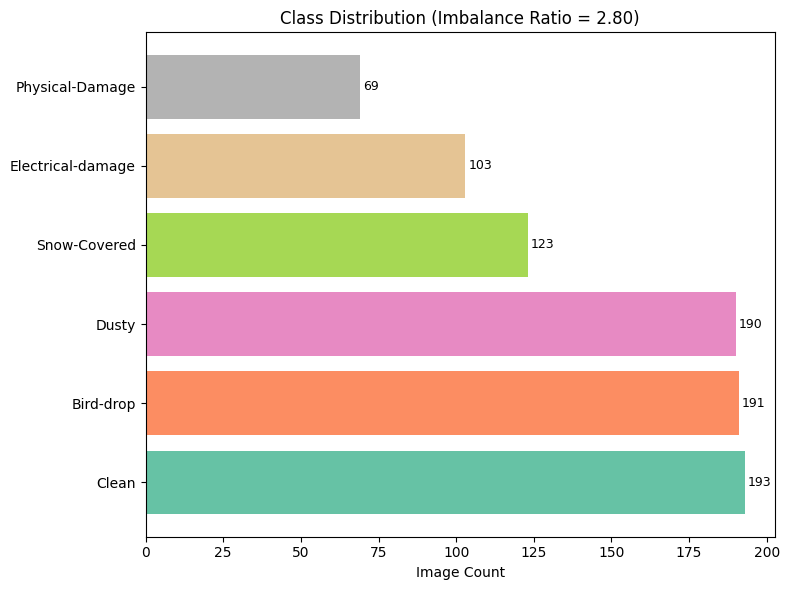

In [20]:
# --- Bar Chart ---
fig1, ax1 = plt.subplots(figsize=(8, 6))

colors = plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES))

ax1.barh(counts.index, counts.values, color=colors)
ax1.set_xlabel('Image Count')
ax1.set_title(f'Class Distribution (Imbalance Ratio = {imbalance_ratio:.2f})')

for i, v in enumerate(counts.values):
    ax1.text(v + 1, i, str(v), va='center', fontsize=9)

plt.tight_layout()
# plt.savefig(f'{OUTPUT_DIR}/eda_class_distribution_bar.png',
#             dpi=150, bbox_inches='tight')
plt.show()

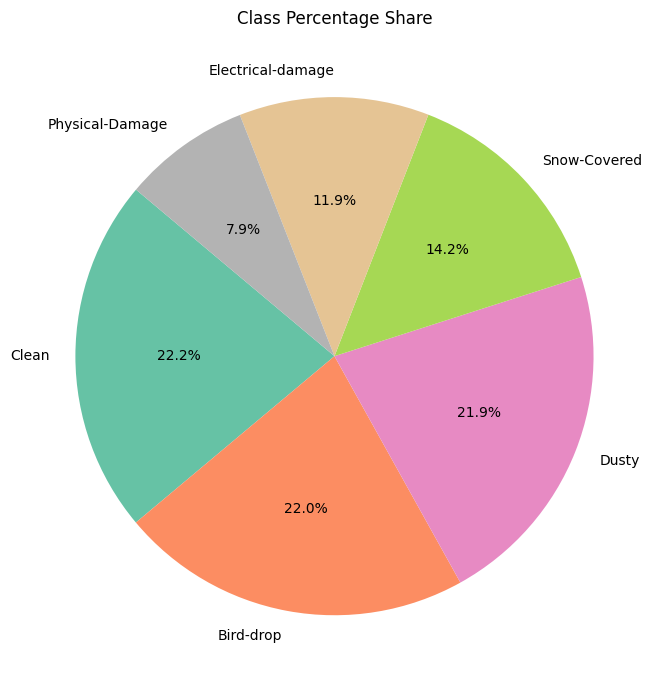

Imbalance ratio (max/min): 2.80


In [21]:
# --- Pie Chart ---
fig2, ax2 = plt.subplots(figsize=(7, 7))

ax2.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140
)

ax2.set_title('Class Percentage Share')

plt.tight_layout()
# plt.savefig(f'{OUTPUT_DIR}/eda_class_distribution_pie.png',
#             dpi=150, bbox_inches='tight')
plt.show()


print(f'Imbalance ratio (max/min): {imbalance_ratio:.2f}')

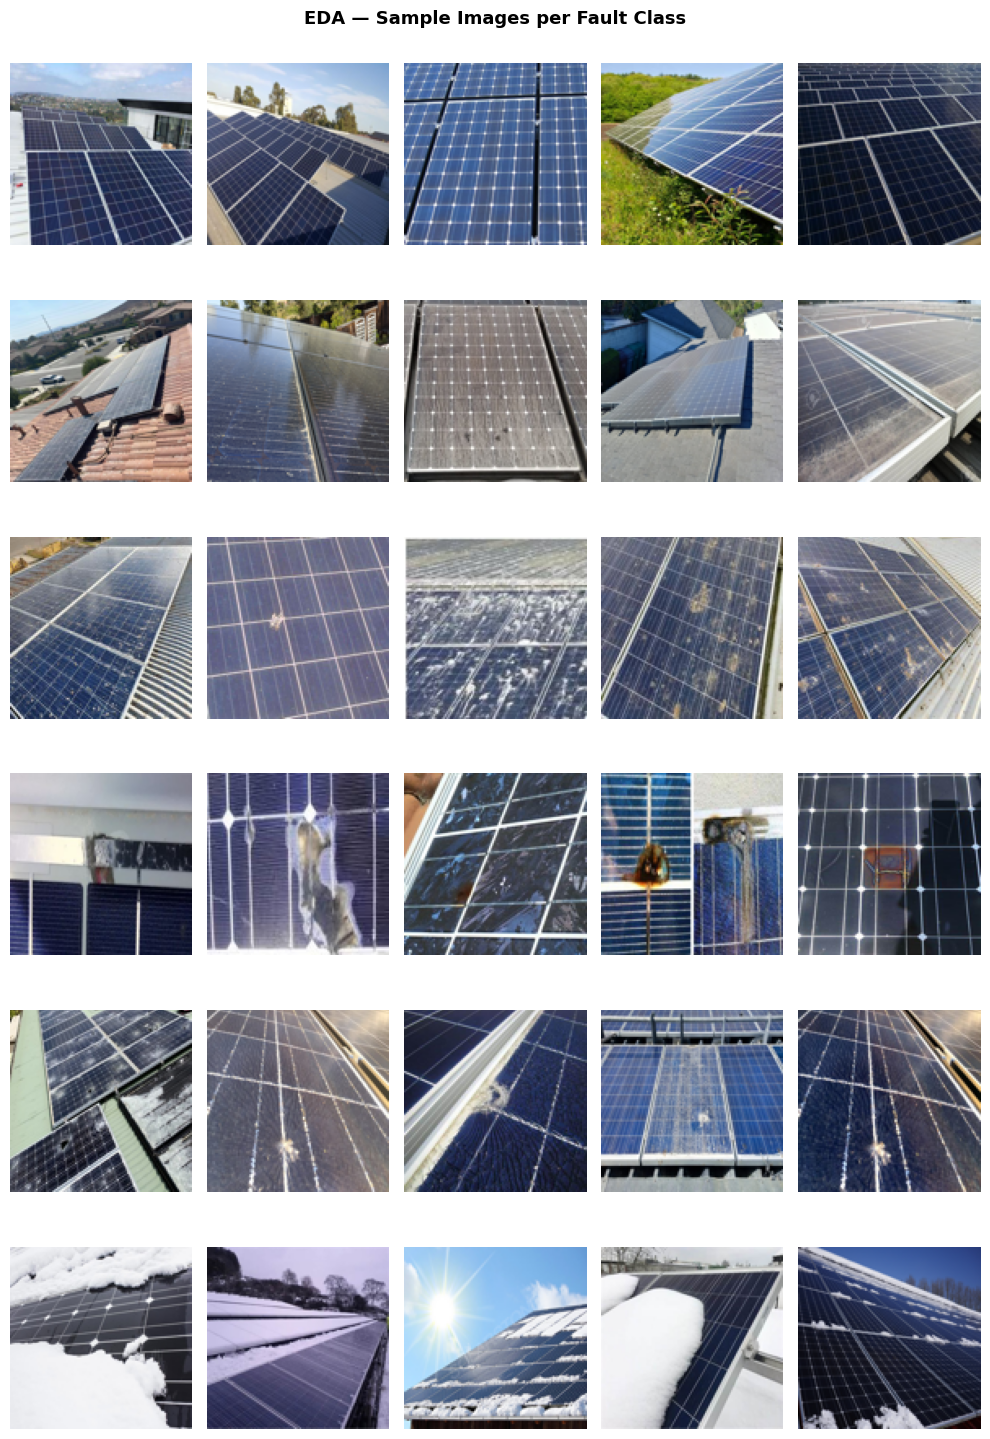

In [22]:
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(10, NUM_CLASSES * 2.5))
fig.suptitle('EDA — Sample Images per Fault Class', fontsize=13, fontweight='bold')

for row_idx, cls in enumerate(CLASS_NAMES):
    cls_paths = df[df['label'] == cls]['path'].sample(
        min(5, len(df[df['label'] == cls])), random_state=SEED
    ).values
    for col_idx, path in enumerate(cls_paths):
        img = Image.open(path).convert('RGB').resize((112, 112))
        axes[row_idx][col_idx].imshow(img)
        axes[row_idx][col_idx].axis('off')
        if col_idx == 0:
            axes[row_idx][col_idx].set_ylabel(cls, fontsize=9, rotation=0,
                                               labelpad=55, va='center')

plt.tight_layout()
#plt.savefig(f'{OUTPUT_DIR}/eda_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

Computing image statistics

── Mean Brightness per Class ──
label
Bird-drop            119.07
Clean                106.11
Dusty                129.41
Electrical-damage     99.59
Physical-Damage      111.46
Snow-Covered         145.86


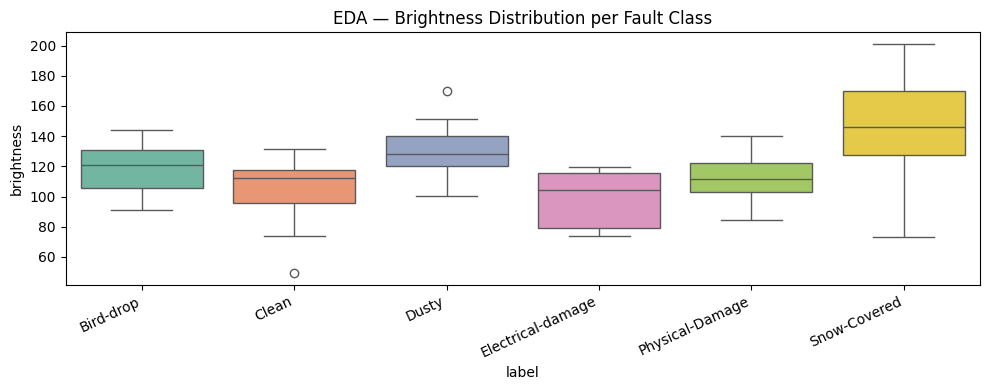

In [23]:
print('Computing image statistics')
stats = []
sample_df = df.groupby('label').apply(lambda x: x.sample(min(20, len(x)),
                                       random_state=SEED)).reset_index(drop=True)

for _, row in sample_df.iterrows():
    try:
        img = np.array(Image.open(row['path']).convert('RGB'))
        stats.append({
            'label'   : row['label'],
            'height'  : img.shape[0],
            'width'   : img.shape[1],
            'mean_r'  : img[:,:,0].mean(),
            'mean_g'  : img[:,:,1].mean(),
            'mean_b'  : img[:,:,2].mean(),
            'std'     : img.std(),
            'brightness': img.mean()
        })
    except Exception:
        pass

stats_df = pd.DataFrame(stats)
print('\n── Mean Brightness per Class ──')
print(stats_df.groupby('label')['brightness'].mean().round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=stats_df, x='label', y='brightness', palette='Set2', ax=ax)
ax.set_title('EDA — Brightness Distribution per Fault Class')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
plt.tight_layout()
#plt.savefig(f'{OUTPUT_DIR}/eda_brightness.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
#Remove corrupt / unreadable files
valid_paths, valid_labels = [], []
corrupt_count = 0

for path, label in zip(df['path'], df['label']):
    try:
        img = Image.open(path).convert('RGB')
        arr = np.array(img)
        if arr.shape[2] == 3 and arr.size > 0:
            valid_paths.append(path)
            valid_labels.append(label)
        else:
            corrupt_count += 1
    except Exception:
        corrupt_count += 1

print(f'Total images    : {len(df)}')
print(f'Corrupt removed : {corrupt_count}')
print(f'Valid images    : {len(valid_paths)}')

Total images    : 869
Corrupt removed : 0
Valid images    : 869


In [25]:
# Duplicate removal using perceptual hashing (pHash)
print('Running perceptual hash duplicate detection...')
seen_hashes = {}
unique_paths, unique_labels = [], []
duplicate_count = 0
HAMMING_THRESHOLD = 10

for path, label in zip(valid_paths, valid_labels):
    try:
        img  = Image.open(path).convert('RGB')
        phash = imagehash.phash(img)
        is_dup = any(
            abs(phash - h) <= HAMMING_THRESHOLD
            for h in seen_hashes
        )
        if not is_dup:
            seen_hashes[phash] = path
            unique_paths.append(path)
            unique_labels.append(label)
        else:
            duplicate_count += 1
    except Exception as e:
        print(e)
        pass

clean_df = pd.DataFrame({'path': unique_paths, 'label': unique_labels})
print(f'Duplicates removed : {duplicate_count}')
print(f'Clean dataset size : {len(clean_df)}')

Running perceptual hash duplicate detection...
Duplicates removed : 179
Clean dataset size : 690


In [28]:
#Encode labels
le = LabelEncoder()
clean_df['label_enc'] = le.fit_transform(clean_df['label'])
print('Label encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

Label encoding: {'Bird-drop': np.int64(0), 'Clean': np.int64(1), 'Dusty': np.int64(2), 'Electrical-damage': np.int64(3), 'Physical-Damage': np.int64(4), 'Snow-Covered': np.int64(5)}


In [29]:
# Stratified 70/15/15 split ─────────────────────────────────────────
X = clean_df['path'].values
y = clean_df['label_enc'].values
#print(f'\nDataset split (x{X})')
#print(f'\nDataset split (y{y})')
TRAIN_SPLIT = 0.70

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=(1 - TRAIN_SPLIT), stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp, random_state=SEED
)

print(f'\nDataset split (stratified, seed={SEED})')
print(f'  Train      : {len(X_train):>5}  ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Validation : {len(X_val):>5}  ({len(X_val)/len(X)*100:.1f}%)')
print(f'  Test       : {len(X_test):>5}  ({len(X_test)/len(X)*100:.1f}%)')


Dataset split (stratified, seed=42)
  Train      :   482  (69.9%)
  Validation :   104  (15.1%)
  Test       :   104  (15.1%)


In [30]:
#Class weights for imbalance handling
class_weights_arr = compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train), y=y_train
)
class_weights = dict(enumerate(class_weights_arr))
print(f'\nClass weights: {class_weights}')


Class weights: {0: np.float64(1.0299145299145298), 1: np.float64(0.6426666666666667), 2: np.float64(0.6478494623655914), 3: np.float64(1.4876543209876543), 4: np.float64(2.4343434343434343), 5: np.float64(1.1813725490196079)}


In [32]:
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32
DROPOUT_RATE  = 0.40
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [49]:
def preprocess_image(image_path, target_size=IMG_SIZE):
    """
    Load and preprocess image using MobileNetV2's required normalisation.
    preprocess_input maps [0,255] → [-1, 1] exactly as the backbone expects.
    """
    img = Image.open(image_path).convert('RGB')
    img = img.resize(target_size, Image.BICUBIC)
    arr = np.array(img, dtype=np.float32)
    arr = preprocess_input(arr)          # maps [0,255] → [-1, 1]
    return arr.astype(np.float32)        # guarantee float32 output

print('preprocess_image defined — using MobileNetV2 preprocess_input ([-1,1] range)')

preprocess_image defined — using MobileNetV2 preprocess_input ([-1,1] range)


In [50]:
def build_tf_dataset(paths, labels, augment=False, batch_size=BATCH_SIZE):
    def load_fn(path, label):
        img = tf.numpy_function(
            lambda p: preprocess_image(p.decode()),
            [path], tf.float32
        )
        img = tf.cast(img, tf.float32)   # safety cast
        img.set_shape([*IMG_SIZE, 3])
        label = tf.one_hot(label, NUM_CLASSES)
        return img, label

    def augment_fn(img, label):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.random_brightness(img, max_delta=0.2)
        img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
        img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, tf.int32))
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_fn, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.shuffle(512, seed=SEED)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = build_tf_dataset(X_train, y_train, augment=True)
val_ds   = build_tf_dataset(X_val,   y_val,   augment=False)
test_ds  = build_tf_dataset(X_test,  y_test,  augment=False)

print(f'Train batches      : {len(train_ds)}')
print(f'Validation batches : {len(val_ds)}')
print(f'Test batches       : {len(test_ds)}')

Train batches      : 16
Validation batches : 4
Test batches       : 4


In [51]:
def build_mobilenetv2_model(num_classes=NUM_CLASSES, dropout_rate=DROPOUT_RATE):
    # Load pre-trained backbone (no top layer)
    backbone = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=IMG_SHAPE      # use input_shape, NOT input_tensor
    )
    # Phase 1: freeze all backbone weights
    backbone.trainable = False

    # Build model on top of backbone's own input tensor
    inputs = keras.Input(shape=IMG_SHAPE)

    # training=False keeps BatchNorm in inference mode during Phase 1.
    # Without this, BN running stats get corrupted even when backbone.trainable=False
    x = backbone(inputs, training=False)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs, name='MobileNetV2_SolarFault')
    model.compile(
        optimizer=keras.optimizers.Adam(LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model, backbone


def get_callbacks(model_name, phase=''):
    name = f'{model_name}_{phase}' if phase else model_name
    return [
        EarlyStopping(
            monitor='val_loss', patience=10,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=5, min_lr=1e-8, verbose=1
        ),
        ModelCheckpoint(
            filepath=f'{OUTPUT_DIR}/{name}_best.keras',
            monitor='val_accuracy', save_best_only=True, verbose=0
        )
    ]

print('Model builder ready.')

Model builder ready.


In [54]:
print('=' * 55)
print('  MobileNetV2 — Two-Phase Training')
print('=' * 55)

mv2_model, mv2_base = build_mobilenetv2_model()

total_params     = mv2_model.count_params()
trainable_params = sum(v.numpy().size for v in mv2_model.trainable_variables)
print(f'Total parameters     : {total_params:,}')
print(f'Trainable (Phase 1)  : {trainable_params:,}')
print(f'Frozen (backbone)    : {total_params - trainable_params:,}')

# ── Phase 1: frozen backbone, train head only ──────────────────────────────
print(f'\nPhase 1: Training head ({EPOCHS_PHASE1} epochs max, LR={LEARNING_RATE})')
t0 = time.time()

hist1 = mv2_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    class_weight=class_weights,
    callbacks=get_callbacks('mv2', 'phase1'),
    verbose=1
)

# ── Phase 2: unfreeze top 30% of backbone ─────────────────────────────────
print(f'\nPhase 2: Fine-tuning top 30% of backbone ({EPOCHS_PHASE2} epochs max, LR={FINETUNE_LR})')

mv2_base.trainable = True
total_layers  = len(mv2_base.layers)
freeze_up_to  = int(total_layers * 0.70)

for layer in mv2_base.layers[:freeze_up_to]:
    layer.trainable = False

trainable_p2 = sum(v.numpy().size for v in mv2_model.trainable_variables)
print(f'  Backbone layers total   : {total_layers}')
print(f'  Layers kept frozen      : {freeze_up_to}')
print(f'  Layers unfrozen         : {total_layers - freeze_up_to}')
print(f'  Trainable params now    : {trainable_p2:,}')

mv2_model.compile(
    optimizer=keras.optimizers.Adam(FINETUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

hist2 = mv2_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    class_weight=class_weights,
    callbacks=get_callbacks('mv2', 'phase2'),
    verbose=1
)

train_time = time.time() - t0
best_val = max(
    max(hist1.history['val_accuracy']),
    max(hist2.history['val_accuracy'])
)
print(f'\nTraining complete.')
print(f'  Total time     : {train_time/60:.1f} minutes')
print(f'  Best val acc   : {best_val:.4f}')

  MobileNetV2 — Two-Phase Training
Total parameters     : 2,270,790
Trainable (Phase 1)  : 10,246
Frozen (backbone)    : 2,260,544

Phase 1: Training head (30 epochs max, LR=0.0001)
Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.1577 - loss: 2.6936 - val_accuracy: 0.2885 - val_loss: 1.8776 - learning_rate: 1.0000e-04
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.1701 - loss: 2.6892 - val_accuracy: 0.3173 - val_loss: 1.7794 - learning_rate: 1.0000e-04
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.1971 - loss: 2.4873 - val_accuracy: 0.3365 - val_loss: 1.6954 - learning_rate: 1.0000e-04
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.2344 - loss: 2.3826 - val_accuracy: 0.3750 - val_loss: 1.6285 - learning_rate: 1.0000e-04
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.2884 - loss: 2.2239 - val_accuracy: 0.3942 - val_loss: 1.5741 - learning_rate: 1.0000e-04
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 91s 3s/ste